In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, std_dev, nominal_value
from uncertainties.unumpy import nominal_values, std_devs, uarray

# Create calibrated Spectrum 
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

# domain charactrization
from pyspectrum.domain_analysis.characterization.morphology import find_domain_peaks, find_domain_peaks_cwt

# load the spectrum

In [2]:
path = '../Library/Doppler_broadening_Spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.05
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))


energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_file(path, energy_calibration=energy_calib, fwhm_calibration=res_calib,
                                        num_of_channels=16384, chunk_size=int(10000),
                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

(300.0, 700.0)

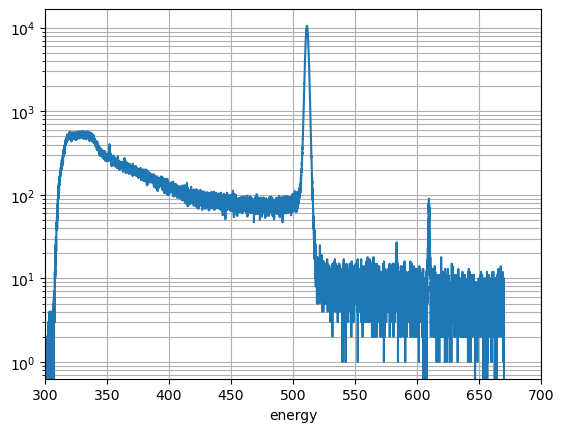

In [3]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.xlim([300,700])

# Domains identification

In [5]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=0.5)
domains = finder.find(spectrum)
domain = domains[-1]

example how to use a domains - 

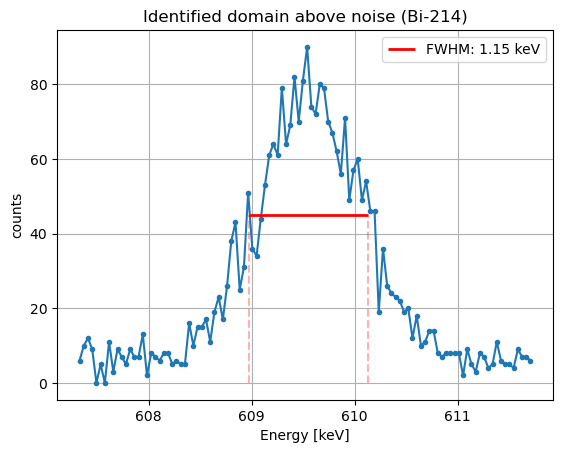

In [6]:
# 1. Calculations
mean_energy = (domain.data.energy * domain.data).sum() / domain.data.sum()
fwhm = domain.local_resolution
max_counts = domain.data.max()
half_max = max_counts / 2

# 2. Plotting
domain.plot(marker='.')
plt.grid(True, which='both')
plt.title('Identified domain above noise (Bi-214)')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

# 3. Add the FWHM Bar
# xmin and xmax define the edges of the resolution bar
plt.hlines(y=half_max, 
           xmin=mean_energy - (fwhm / 2), 
           xmax=mean_energy + (fwhm / 2), 
           colors='r', linestyles='-', lw=2, label=f'FWHM: {fwhm:.2f} keV')

# Optional: Add vertical dashed lines to "anchor" the bar to the axis
plt.vlines(x=[mean_energy - (fwhm / 2), mean_energy + (fwhm / 2)], 
           ymin=0, ymax=half_max, colors='r', linestyles='--', alpha=0.3)

plt.legend()
plt.show()

using the domain charectarzation methods 

In [9]:
find_peaks_cwt_mean = find_domain_peaks_cwt(domain)
find_peaks_mean, find_peaks_prop = find_domain_peaks(domain, smoothing_fwhm_scale=0.3)

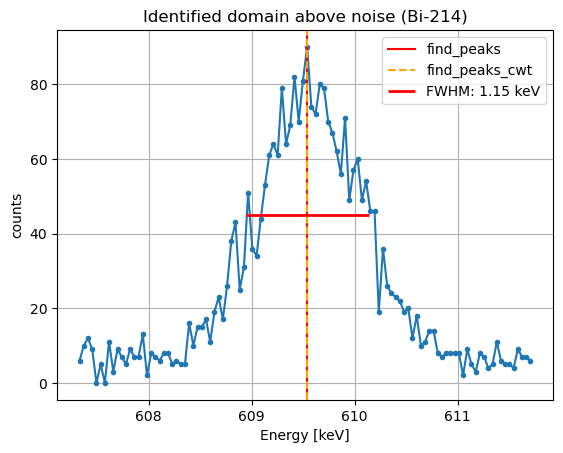

In [12]:
domain.plot(marker='.')
plt.grid(True, which='both')
plt.title('Identified domain above noise (Bi-214)')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

plt.axvline(x=find_peaks_mean, color='r', label='find_peaks')
plt.axvline(x=find_peaks_cwt_mean, color='orange', ls='--', label='find_peaks_cwt')

plt.hlines(y=half_max, 
           xmin=find_peaks_mean - (find_peaks_prop['fwhm'][0] / 2), 
           xmax=find_peaks_mean + (find_peaks_prop['fwhm'][0] / 2), 
           colors='r', linestyles='-', lw=2, label=f'FWHM: {fwhm:.2f} keV')

plt.legend()
